# NLP Practical 1: Word Embeddings & Sequence Processing

Welcome to the first practical session of the NLP block! Today we will cover two core foundations:
1. Word Embeddings & `nn.Embedding`: How words become dense vectors, and how PyTorch manages them under the hood.
2. Sequence Processing with LSTMs: Processing sequential tokens and building a sentiment classifier.

### Understanding the `nn.Embedding` Layer
A common question when starting NLP in PyTorch is: *Why don't we pass dense Word2Vec vectors directly through our DataLoader?*

If a review contains $200$ words and each word vector is $300$-dimensional, storing floating-point vectors for every single word in a large dataset would require gigabytes of RAM and slow down data transfer to the GPU.

Instead, we use a two-step approach:
1. Tokenizer / Vocabulary: Map every unique word in our dataset to an integer ID (e.g., "the" $\to 1$, "movie" $\to 402$, "great" $\to 1895$).
2. `nn.Embedding`: A lookup table stored in GPU memory as a weight matrix of shape $[\vert{}V\vert{}, d]$, where $\vert{}V\vert{}$ is the vocabulary size and $d$ is the vector dimension.

When you pass a tensor of word IDs [1, 402, 1895] into nn.Embedding, it performs an $O(1)$ index lookup and returns rows $1$, $402$, and $1895$ from its weight matrix.

### Loading Pre-trained Word2Vec Weights into nn.Embedding
If you have pre-trained Word2Vec vectors (e.g., from Gensim), you can directly inject those weights into a PyTorch `nn.Embedding` layer using `nn.Embedding.from_pretrained()`:

```python
# Convert Gensim Word2Vec matrix to a PyTorch tensor
weights = torch.FloatTensor(w2v_model.wv.vectors)

# Create the embedding layer initialized with Word2Vec weights
embedding_layer = nn.Embedding.from_pretrained(weights, freeze=False)
```

* `freeze=True`: Keeps Word2Vec vectors static during training.
* `freeze=False`: Allows backpropagation to fine-tune Word2Vec vectors specifically for your downstream task (e.g., Sentiment Analysis).

In [ ]:
import torch
import torch.nn as nn
import numpy as np

# --- Demo: How nn.Embedding acts as a Lookup Table ---
vocab_size = 10
embed_dim = 4

# Initialize a random embedding layer
emb = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embed_dim)

# Inspect the underlying lookup matrix (Shape: [10, 4])
print("Embedding Weight Matrix:")
print(emb.weight.data)

# Pass integer token IDs (e.g., a batch of 2 sequences, each of length 3)
token_ids = torch.tensor([[1, 4, 2],
                          [0, 9, 3]])

# Lookup operation
embedded_output = emb(token_ids)
print("\nOutput Tensor Shape:", embedded_output.shape) # [batch_size, seq_len, embed_dim]
print("Retrieved Vector for Token ID 4 (Row 4):")
print(embedded_output[0, 1])

Embedding Weight Matrix:
tensor([[-0.2914, -0.6761,  0.2647, -2.1168],
        [-0.6814, -0.6305,  0.8027, -0.4623],
        [-0.5560,  0.1545,  1.7229,  1.0767],
        [ 0.7920,  0.1189, -1.2270, -0.5842],
        [-0.1395,  0.1123, -0.2732, -1.2495],
        [-0.1289, -2.5119,  1.7771, -1.1275],
        [-0.1119, -0.2553,  1.4905,  0.0260],
        [ 0.7450,  0.3509,  0.1269, -1.1020],
        [ 0.1038,  0.0532,  0.7636,  0.2962],
        [-0.5998, -0.5560, -0.8559, -0.8069]])

Output Tensor Shape: torch.Size([2, 3, 4])
Retrieved Vector for Token ID 4 (Row 4):
tensor([-0.1395,  0.1123, -0.2732, -1.2495], grad_fn=<SelectBackward0>)


## Part 1: Training & Visualizing Armenian Word2Vec Embeddings
Let's load a subset of Armenian Wikipedia, train a Word2Vec model on it, convert its vectors to a PyTorch `nn.Embedding` layer, and project the high-dimensional vectors to 2D space using Principal Component Analysis (PCA).

In [ ]:
# !pip install datasets
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 35.6 MB/s eta 0:00:00


README.md:   0%|          | 0.00/131k [00:00<?, ?B/s]

20231101.hy/train-00000-of-00003.parquet: reconstructing file:   0%|          |  0.00B / 97.0MB            

20231101.hy/train-00000-of-00003.parquet: downloading bytes:           |  0.00B            

20231101.hy/train-00001-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  127MB            

20231101.hy/train-00001-of-00003.parquet: downloading bytes:           |  0.00B            

20231101.hy/train-00002-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  266MB            

20231101.hy/train-00002-of-00003.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/303036 [00:00<?, ? examples/s]

Tokenizing corpus...
Training Word2Vec model...
Successfully created PyTorch Embedding layer with shape: torch.Size([36447, 100])


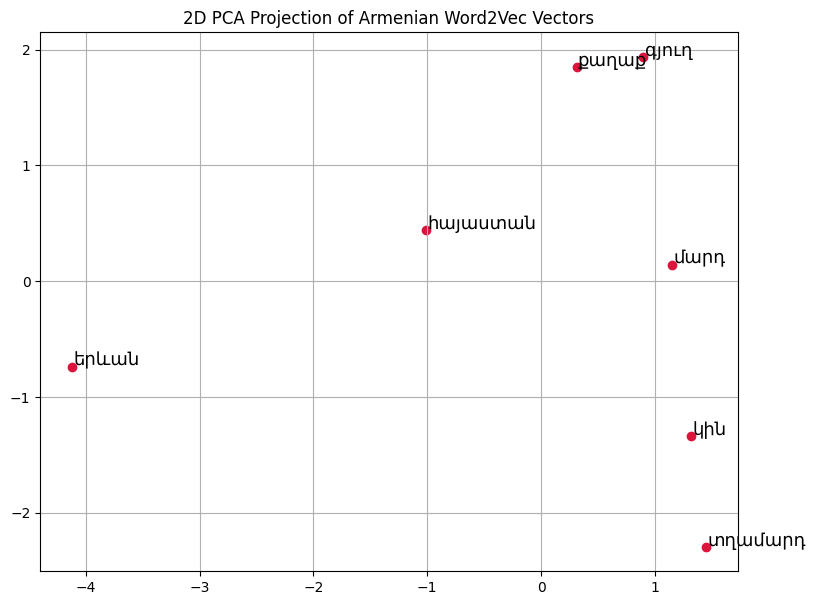

In [ ]:
import re
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from gensim.models import Word2Vec
from sklearn.decomposition import PCA

# 1. Load 1% snapshot of Armenian Wikipedia
print("Downloading Armenian Wikipedia dump...")
dataset = load_dataset("wikimedia/wikipedia", "20231101.hy", split="train[:1%]")

# 2. Simple tokenizer for Armenian alphabet
def tokenize_am(text):
    text = text.lower()
    text = re.sub(r'[^ա-ֆև ]+', '', text)
    return text.split()

print("Tokenizing corpus...")
corpus = [tokenize_am(article['text']) for article in dataset]

# 3. Train Word2Vec Skip-Gram model
print("Training Word2Vec model...")
w2v_model = Word2Vec(sentences=corpus, vector_size=100, window=5, min_count=5, sg=1, workers=4)

# 4. Extract weights and load into PyTorch nn.Embedding
w2v_weights = torch.FloatTensor(w2v_model.wv.vectors)
nn_embedding_am = nn.Embedding.from_pretrained(w2v_weights, freeze=False)
print(f"Successfully created PyTorch Embedding layer with shape: {nn_embedding_am.weight.shape}")

# 5. Visualize select words using PCA
target_words = ['երևան', 'հայաստան', 'քաղաք', 'գյուղ', 'մարդ', 'կին', 'տղամարդ']
valid_words = [w for w in target_words if w in w2v_model.wv]
vectors = np.array([w2v_model.wv[w] for w in valid_words])

pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(vectors)

plt.figure(figsize=(9, 7))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], color='crimson')
for i, word in enumerate(valid_words):
    plt.annotate(word, (vectors_2d[i, 0] + 0.01, vectors_2d[i, 1] + 0.01), fontsize=13)
plt.title("2D PCA Projection of Armenian Word2Vec Vectors")
plt.grid(True)
plt.show()

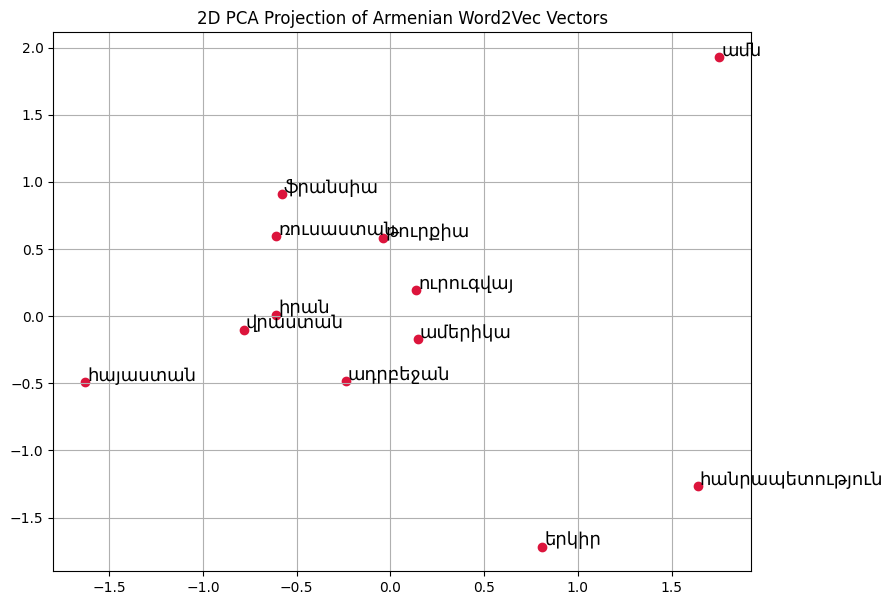

In [ ]:
target_words = ['հանրապետություն', 'երկիր', 'ռուսաստան', 'թուրքիա', 'ամն', 'ամերիկա', 'ուրուգվայ', 'իրան', 'ֆրանսիա', 'հայաստան', 'վրաստան', 'ադրբեջան']
valid_words = [w for w in target_words if w in w2v_model.wv]
vectors = np.array([w2v_model.wv[w] for w in valid_words])

pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(vectors)

plt.figure(figsize=(9, 7))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], color='crimson')
for i, word in enumerate(valid_words):
    plt.annotate(word, (vectors_2d[i, 0] + 0.01, vectors_2d[i, 1] + 0.01), fontsize=13)
plt.title("2D PCA Projection of Armenian Word2Vec Vectors")
plt.grid(True)
plt.show()

For more interesting embedding visualizations, check https://projector.tensorflow.org/.

## Part 2: The PyTorch Shape Trap (`batch_first=True`)
In Computer Vision, tensor shapes are almost universally `[batch_size, channels, height, width]`.

By default, PyTorch's nn.LSTM expects inputs in the shape `[seq_len, batch_size, embed_dim]`.Passing a standard batch of shape `[batch_size, seq_len, embed_dim]` without configuring the layer will lead to shape mismatch errors.

Always explicitly set `batch_first=True` when instantiating `nn.LSTM` to keep the batch size as the first dimension:
$$\text{Input Shape: } [N, T, d]$$
$$\text{Output Shape: } [N, T, m]$$

Where $N$ is the batch size, $T$ is the sequence length, $d$ is the embedding dimension, and $m$ is the hidden state dimension.

In [ ]:
batch_size = 16
seq_len = 50
embed_dim = 100
hidden_dim = 256

# Initialize LSTM with batch_first=True
lstm = nn.LSTM(input_size=embed_dim, hidden_size=hidden_dim, batch_first=True)

# Generate dummy embedded input: [batch_size, seq_len, embed_dim]
dummy_embeddings = torch.randn(batch_size, seq_len, embed_dim)

# Forward pass through LSTM
# output: contains hidden states for ALL time steps [batch_size, seq_len, hidden_dim]
# (h_n, c_n): contains final states [num_layers, batch_size, hidden_dim]
output, (h_n, c_n) = lstm(dummy_embeddings)

print("Full Sequence Output Shape (out):", output.shape)
print("Final Hidden State Shape (h_n):   ", h_n.shape)

# Extracting the last hidden state h_T for sentiment classification
# Method A: From output tensor
h_T_from_out = output[:, -1, :] # [batch_size, hidden_dim]

# Method B: From h_n tuple
h_T_from_hn = h_n.squeeze(0)    # [batch_size, hidden_dim]

print("Extracted Final Vector Shape:    ", h_T_from_hn.shape)

Full Sequence Output Shape (out): torch.Size([16, 50, 256])
Final Hidden State Shape (h_n):    torch.Size([1, 16, 256])
Extracted Final Vector Shape:     torch.Size([16, 256])


## Part 3: DIY Sentiment Analysis (IMDB Dataset)

Now complete the implementation of `SentimentLSTM`.

**Requirements**:
1. Initialize nn.Embedding (Optionally load Word2Vec weights if provided).
2. Instantiate `nn.LSTM` with `batch_first=True`.
3. Extract the final hidden state $h_T$ corresponding to the last word of each review.
4. Pass $h_T$ into a linear layer to output binary classification logits.

In [ ]:
class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, pretrained_vectors=None):
        super().__init__()

        if pretrained_vectors is not None:
            self.embedding = nn.Embedding.from_pretrained(pretrained_vectors, freeze=False)
        else:
            self.embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embed_dim)

        # TODO: Initialize nn.LSTM with batch_first=True
        self.lstm = None

        # TODO: Initialize an nn.Linear layer mapping from hidden_dim to 1
        self.fc = None

    def forward(self, x):
        """
        x shape: [batch_size, seq_len] (Integer Token IDs)
        """
        # 1. Look up embeddings -> [batch_size, seq_len, embed_dim]
        embeds = ...

        # TODO: 2. Pass the embedded output through the LSTM.
        # Hint: The LSTM returns two things: the full sequence output AND a tuple (h_n, c_n).


        # TODO: 3. Extract the final hidden state h_T for the batch.
        # Hint: You can get this from h_n. Be careful with the shape!
        # h_n shape is [1, batch_size, hidden_dim]. You need [batch_size, hidden_dim].


        # TODO: 4. Pass the extracted state through the fully connected layer.


        return None # Return the final logits. Make sure the shape is [batch_size] (use .squeeze())

# --- Sanity Check ---
# Run this cell to test your tensor shapes!
test_vocab_size = 5000
test_model = SentimentLSTM(vocab_size=test_vocab_size, embed_dim=100, hidden_dim=128)
dummy_tokens = torch.randint(0, test_vocab_size, (8, 200)) # Batch of 8 reviews, length 200
test_logits = test_model(dummy_tokens)

print("Output Logits Shape:", test_logits.shape) # Should be [8]
assert test_logits.shape == torch.Size([8]), "Shape check failed! Check your squeeze() operations."
print("Sanity Check Passed!")

### Data Preparation
The code to download the IMDB dataset, build a simple vocabulary, and construct the PyTorch DataLoader is provided below.

(Note: We are taking a small subset of the training data so you can train your model quickly during this practical session).

In [ ]:
from datasets import load_dataset
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence
import torch.optim as optim
from collections import Counter
import re

# 1. Load IMDB (Using a small subset for classroom speed)
print("Loading IMDB Dataset...")
dataset = load_dataset("stanfordnlp/imdb")
train_data = dataset['train'].shuffle(seed=42).select(range(2000))
test_data = dataset['test'].shuffle(seed=42).select(range(500))

# 2. Simple Tokenizer & Vocabulary Builder
def tokenize(text):
    return re.sub(r'[^a-z ]+', '', text.lower()).split()

print("Building vocabulary...")
all_words = [word for item in train_data for word in tokenize(item['text'])]
vocab = {word: i+2 for i, (word, _) in enumerate(Counter(all_words).most_common(10000))}
vocab['<PAD>'] = 0
vocab['<UNK>'] = 1

def encode(text):
    return [vocab.get(word, vocab['<UNK>']) for word in tokenize(text)][:250] # Cap at 250 words

# 3. Collate function for DataLoader (Padding)
def collate_fn(batch):
    sequences = [torch.tensor(encode(item['text'])) for item in batch]
    labels = torch.tensor([item['label'] for item in batch]).float()
    padded_seqs = pad_sequence(sequences, batch_first=True, padding_value=0)
    return padded_seqs, labels

train_loader = DataLoader(train_data, batch_size=32, shuffle=True, collate_fn=collate_fn)
print("DataLoader ready!")

Loading IMDB Dataset...


README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 21.0MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.5MB            

...

plain_text/unsupervised-00000-of-00001.p(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Building vocabulary...
DataLoader ready!


In [ ]:
next(iter(train_loader))[0]

tensor([[  50,    2, 2835,  ...,    0,    0,    0],
        [1786, 1621,   50,  ...,   23,  130,  335],
        [   8,    1,  698,  ...,    0,    0,    0],
        ...,
        [ 138,  130,  158,  ...,   49,   23,   38],
        [   9,   63,  123,  ...,   36,  670,   11],
        [ 186, 6486,    4,  ...,    0,    0,    0]])

### Training Loop
Now that your SentimentLSTM is defined and the data is ready, it is time to train.

**Your Task**:

1. Initialize your device (GPU if available, else CPU), the model, the loss function (`BCEWithLogitsLoss`), and the optimizer (`Adam`).
2. Write the standard PyTorch training loop for 3 epochs.

In [ ]:
# TODO: 1. Initialize your device
device = None

# TODO: 2. Initialize your SentimentLSTM model and move it to the device
model = None

# TODO: 3. Initialize nn.BCEWithLogitsLoss and optim.Adam (try a learning rate of 0.001)
criterion = None
optimizer = None

print(f"Training on {device}...")

# TODO: 4. Set the model to training mode
# model.???()

# TODO: 5. Write the training loop
epochs = 3
for epoch in range(epochs):
    total_loss = 0

    # Iterate over train_loader
    for batch_idx, (texts, labels) in enumerate(train_loader):
        # A. Move texts and labels to your device

        # B. Zero the gradients

        # C. Forward pass

        # D. Calculate loss

        # E. Backward pass

        # F. Optimizer step

        # G. Add loss.item() to total_loss
        pass # Remove this pass when you write the loop

    # Print the average loss for the epoch
    # print(f"Epoch {epoch+1} | Average Loss: {total_loss/len(train_loader):.4f}")

### Testing & Inference
Let's see how your trained LSTM performs on completely unseen reviews.

**Your Task**:
Write the inference logic to process raw strings, pass them through your trained network, and print out the predicted sentiment.

In [ ]:
# TODO: 1. Set the model to evaluation mode
# model.???()

sample_reviews = [
    "This movie was an absolute masterpiece. The acting was phenomenal.",
    "Terrible. I wasted two hours of my life on this garbage.",
    "It started out a bit slow, but the ending was incredibly satisfying and emotional.",
    "Not good at all. The plot made no sense and the characters were boring."
]

print("--- LSTM Sentiment Predictions ---")

with torch.no_grad():
    for text in sample_reviews:
        # TODO: 2. Encode the text using the provided `encode()` function.

        # TODO: 3. Convert the encoded list to a PyTorch tensor.

        # TODO: 4. TRAP: Your tensor is currently 1D [seq_len]. The model expects [batch_size, seq_len].
        # Use .unsqueeze(0) to add a fake batch dimension of 1, and move it to the device.
        encoded_tensor = None

        # TODO: 5. Pass the tensor through the model to get the logit.
        logit = None

        # TODO: 6. Apply torch.sigmoid() to the logit and extract the scalar float value using .item()
        probability = None

        # TODO: 7. Determine the sentiment label ("POSITIVE" if probability > 0.5 else "NEGATIVE")
        sentiment = None

        # print(f"\nReview: {text}")
        # print(f"Prediction: {sentiment} ({probability:.4f})")